# Задание 1. Исследование набора данных

## <a id="toc" style="text-decoration: none; color:#81BCD9;">Содержание:</a>
<ol style="font-size: 22px;">
    <li><a href="#dataset" style="text-decoration: none; color:#55C385;">Набор данных</a></li>
    <li><a href="#dataset-description" style="text-decoration: none; color:#55C385;">Описание набора данных</a></li>
    <li><a href="#attributes-analysis" style="text-decoration: none; color:#55C385;">Анализ атрибутов</a></li>
    <li><a href="#attributes-correlation" style="text-decoration: none; color:#55C385;">Анализ корреляции атрибутов</a></li>
</ol>

## 1. <a href="#toc" title="К содержанию" id="dataset" style="text-decoration: none; color:#81BCD9;">Набор данных:</a> <a href="https://www.kaggle.com/mczielinski/bitcoin-historical-data" title="Bitcoin Historical Data" style="text-decoration: none; color:#FF8D6F; font-size:15px; font-weight:bold;" rel="noopener noreferrer" target="_blank">Bitcoin Historical Data</a>
***

## 2. <a href="#toc" title="К содержанию" id="dataset-description" style="text-decoration: none; color:#81BCD9;">Описание набора данных</a>
***

### Общая информация
- Предметная область: криптовалюта
- Источник данных: <a href="https://bitcoincharts.com/" title="Bitcoincharts" style="text-decoration: none; color:#FF8D6F; font-weight: bold;" rel="noopener noreferrer" target="_blank">Bitcoincharts</a>
- Характер данных: реальные

### Атрибуты
1. **Timestamp**:`int` — время начала временного окна (каждое окно по $60c$) в формате Unix
2. **Open**:`float` — цена на момент открытия временного окна
3. **High**:`float` — $max_{цена}$ во временном окне
4. **Low**:`float` — $min_{цена}$ во временном окне
5. **Close**:`float` — цена на момент закрытия временного окна
6. **Volume_(BTC)**:`float` — объём транзакции в $BTC$
7. **Volume_(Currency)**:`float` — объём транзакции в валюте
8. **Weighted_Price**:`float` — курс $BTC$ для данной валюты

### Описание задачи анализа отсутствует

## 3. <a href="#toc" title="К содержанию" id="attributes-analysis" style="text-decoration: none; color:#81BCD9">Анализ атрибутов</a>
***

- Среднее значение атрибута <font size="6px">$\overline{x}$</font> буду считать по формуле: <font size="6px">$\overline{x}=\frac{\sum\limits_{i=1}^{N}x_i}{N}$</font>
    - ```python
    mean_attribute = df['attribute'].mean() # attribute — название атрибута
    ```
- Среднеквадратическое отклонение <font size="6px">$s_x$</font> буду считать по формуле: <font size="6px">$s_x=\sqrt{\frac{\sum\limits_{i=1}^{N}(x_i-\overline{x})^2}{N-1}}$</font>
    - ```python
    sd_attribute = df['attribute'].std(ddof=1) # attribute — название атрибута
    ```
- Коэффициент вариации (он тоже будет полезен) буду считать по формуле: <font size="6px">$c_{\scriptscriptstyle V}=\frac{s_x}{\overline{x}}$</font>
    - ```python
    c_v_attribute = sd_attribute / mean_attribute # attribute — название атрибута
    ```
- Для прорисовки гистрограмм буду использовать команду
    - ```python
    plt.hist(df['attribute']); # attribute — название атрибута
    ```
    - Также для диаграмм буду вводить дополнительные переменные и рисунки/надписи для чуть лучшей чем совсем плохая визуализации
- Количество выбросов буду определять с помощью верхней границы межквартильного диапазона по формуле: <font size="6px">$b_u=2.5Q_3-1.5Q_1$</font>
    - ```python
    b_u_attribute = 2.5 * df['attribute'].quantile(0.75) - 1.5 * df['attribute'].quantile(0.25)
    ```
    - ```python
    outliers_amount_attribute = len(df[df['attribute'] > b_u_attribute]) # attribute — название атрибута
    ```
- Количество пропущенных значений буду вычислять подсчётом количества ячеек, где в качестве значения указано `NaN`
    - ```python
    amount_na_attribute = df['attribute'].isna().sum() # attribute — название атрибута
    ```
- Вариантов обработки значений у меня два (зависит от типа анализа): отбросить или оставить

Подключу `pandas`, `seaborn`, `matplotlib.pyplot` и `matplotlib.patches`, после чего установлю стили для гистограмм и введу переменные для них же, после чего считаю файл с набором данных `bitstampUSD_1-min_data_2012-01-01_to_2021-03-31.csv`, после чего покажу на всякий случай атрибуты набора данных.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

sns.set(rc={'figure.figsize':(15,15)})
sns.set_style('white')

thicc = 3
half_thicc = thicc / 2
outliers_text = {'color':  'red', 'weight': 'bold', 'size': 40, 'style': 'italic'}
amount_text = {'family': 'monospace', 'color': '#FFDF5F', 'weight': 'bold', 'size': 30}
font_label = {'fontsize': 20}
arrow = {'arrowstyle': '->', 'ec': 'red', 'lw': thicc}
annotation_box = {'boxstyle': 'round', 'fc': '0.9'}

df = pd.read_csv('bitstampUSD_1-min_data_2012-01-01_to_2021-03-31.csv')

df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4857377 entries, 0 to 4857376
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Timestamp          4857377 non-null  int64  
 1   Open               3613769 non-null  float64
 2   High               3613769 non-null  float64
 3   Low                3613769 non-null  float64
 4   Close              3613769 non-null  float64
 5   Volume_(BTC)       3613769 non-null  float64
 6   Volume_(Currency)  3613769 non-null  float64
 7   Weighted_Price     3613769 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 296.5 MB


### &emsp;1. Timestamp

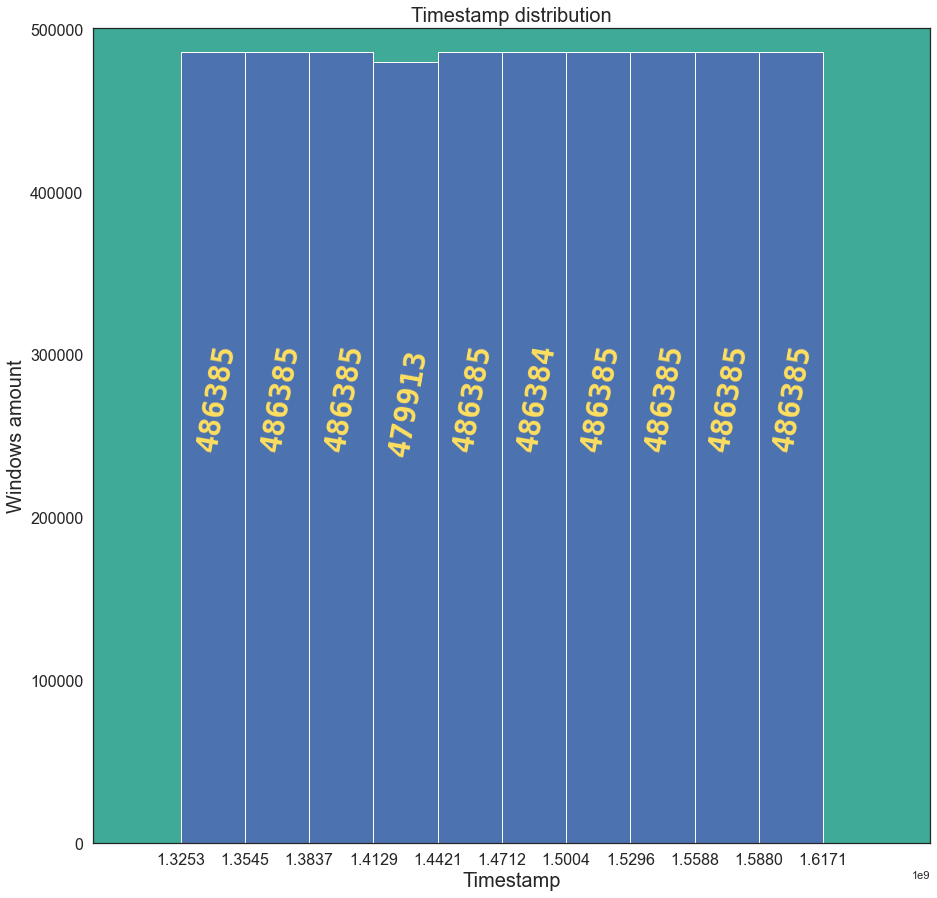

In [2]:
mean_timestamp = df[df.keys()[0]].mean()
sd_timestamp = df[df.keys()[0]].std(ddof=1)
b_u_timestamp = 2.5 * df[df.keys()[0]].quantile(0.75) - 1.5 * df[df.keys()[0]].quantile(0.25)
min_timestamp = df[df.keys()[0]].min()
left_border_timestamp = min_timestamp * 0.97
max_timestamp = df[df.keys()[0]].max()
right_border_timestamp = max_timestamp * 1.03
interval_timestamp = (max_timestamp - min_timestamp) / 10
maximum_timestamp = len(df[df[df.keys()[0]] <= min_timestamp + interval_timestamp])
amounts_timestamp = [maximum_timestamp]
for i in range (1, 10):
    possible_max = len(df[(df[df.keys()[0]] > min_timestamp + i * interval_timestamp)
                        & (df[df.keys()[0]] <= min_timestamp + (i + 1) * interval_timestamp)])
    amounts_timestamp.append(possible_max)
    if maximum_timestamp < possible_max:
        maximum_timestamp = possible_max
ceil_timestamp = maximum_timestamp * 1.03
amount_timestamp = len(df[df.keys()[0]])
amount_na_timestamp = df[df.keys()[0]].isna().sum()
amount_filled_timestamp = len(df[df.keys()[0]]) - amount_na_timestamp
outliers_amount_timestamp = len(df[df[df.keys()[0]] > b_u_timestamp])
outliers_percent_timestamp = outliers_amount_timestamp * 100 / amount_filled_timestamp
non_outliers_amount_timestamp = len(df[df[df.keys()[0]] <= b_u_timestamp])
c_v_timestamp = sd_timestamp / mean_timestamp

plt.axis([left_border_timestamp, right_border_timestamp, 0, ceil_timestamp])
ticks_timestamp = [min_timestamp]
for i in range (1, 11):
    ticks_timestamp.append(i * interval_timestamp + min_timestamp)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xticks(ticks_timestamp)
plt.xlabel(df.keys()[0], font_label)
plt.ylabel('Windows amount', font_label)
plt.title(df.keys()[0] + ' distribution', font_label)
plt.gca().add_patch(patches.Rectangle((0, 0), b_u_timestamp, ceil_timestamp, color='#3FAA98'))
for i in range (0, 10):
        plt.gca().text((2 * min_timestamp + (2 * i + 0.7) * interval_timestamp) / 2.007,
                       amounts_timestamp[i] / 2,
                       amounts_timestamp[i],
                       amount_text,
                       rotation=80)
plt.grid(True)
plt.hist(df[df.keys()[0]]);

In [3]:
print(f'Среднее значение Timestamp:\t\t\t\t\t\t\t\t{mean_timestamp}\n'
f'Среднеквадратическое отклонение Timestamp:\t\t\t\t\t\t{sd_timestamp}\n'
f'Коэффициент вариации Timestamp:\t\t\t\t\t\t\t\t{c_v_timestamp}\n'
f'Верхняя граница межквартильного диапазона Timestamp:\t\t\t\t\t{b_u_timestamp}\n'
f'Количество значений Timestamp всего:\t\t\t\t\t\t\t{amount_timestamp}\n'
f'Количество пропущенных значений Timestamp:\t\t\t\t\t\t{amount_na_timestamp}\n'
f'Количество значений Timestamp без пропущенных:\t\t\t\t\t\t{amount_filled_timestamp}\n'
f'Количество выбросов Timestamp:\t\t\t\t\t\t\t\t{outliers_amount_timestamp}\n'
f'Процент выбросов (от общего значения Timestamp без пропущенных):\t\t\t{outliers_percent_timestamp}\n'
f'Количество значений Timestamp без выбросов:\t\t\t\t\t\t{non_outliers_amount_timestamp}')

Среднее значение Timestamp:								1471300766.5042922
Среднеквадратическое отклонение Timestamp:						84280194.37553182
Коэффициент вариации Timestamp:								0.05728277745397746
Верхняя граница межквартильного диапазона Timestamp:					1763452560.0
Количество значений Timestamp всего:							4857377
Количество пропущенных значений Timestamp:						0
Количество значений Timestamp без пропущенных:						4857377
Количество выбросов Timestamp:								0
Процент выбросов (от общего значения Timestamp без пропущенных):			0.0
Количество значений Timestamp без выбросов:						4857377


Очень бесполезный анализ (конкретно для этого атрибута, когда он отделён от всех остальных). Да, есть небольшая просадка значений в <font size=6px>$4$</font> интервале (<font size=6px>$6472$</font>), но она ни на что не влияет и связана с техническими неполадками в работе API биржи, как заявляет автор.

### &emsp;2. Open

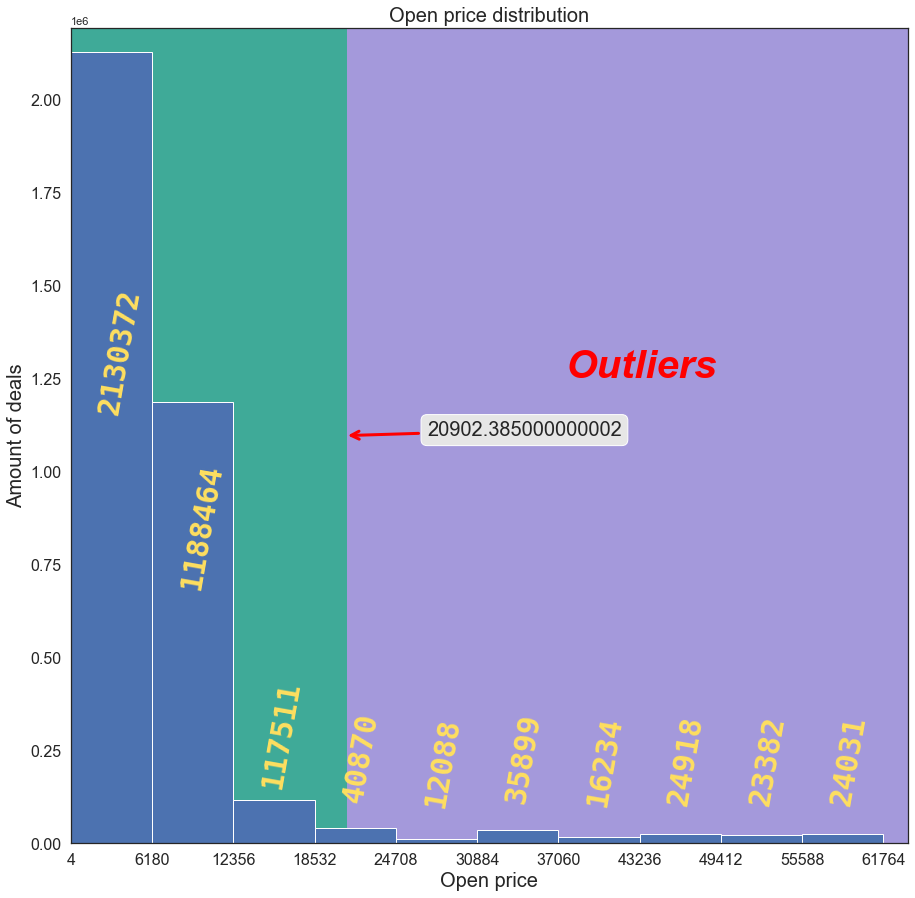

In [4]:
mean_open = df[df.keys()[1]].mean()
sd_open = df[df.keys()[1]].std(ddof=1)
b_u_open = 2.5 * df[df.keys()[1]].quantile(0.75) - 1.5 * df[df.keys()[1]].quantile(0.25)
min_open = df[df.keys()[1]].min()
left_border_open = min_open * 0.97
max_open = df[df.keys()[1]].max()
right_border_open = max_open * 1.03
interval_open = (max_open - min_open) / 10
maximum_open = len(df[df[df.keys()[1]] <= min_open + interval_open])
amounts_open = [maximum_open]
for i in range (1,10):
    possible_max = len(df[(df[df.keys()[1]] > min_open + i * interval_open)
                        & (df[df.keys()[1]] <= min_open + (i + 1) * interval_open)])
    amounts_open.append(possible_max)
    if maximum_open < possible_max:
        maximum_open = possible_max
ceil_open = maximum_open * 1.03
amount_open = len(df[df.keys()[1]])
amount_na_open = df[df.keys()[1]].isna().sum()
amount_filled_open = len(df[df.keys()[1]]) - amount_na_open
outliers_amount_open = len(df[df[df.keys()[1]] > b_u_open])
outliers_percent_open = outliers_amount_open * 100 / amount_filled_open
non_outliers_amount_open = len(df[df[df.keys()[1]] <= b_u_open])
c_v_open = sd_open / mean_open

plt.axis([left_border_open, right_border_open, 0, ceil_open])
ticks_open = [min_open]
for i in range (1, 11):
    ticks_open.append(i * interval_open + min_open)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xticks(ticks_open)
plt.xlabel(df.keys()[1] + ' price', font_label)
plt.ylabel('Amount of deals', font_label)
plt.title(df.keys()[1] + ' price distribution', font_label)
plt.gca().add_patch(patches.Rectangle((b_u_open, 0),
                                      right_border_open - b_u_open,
                                      ceil_open,
                                      color='#A499DB'))
plt.gca().add_patch(patches.Rectangle((0, 0), b_u_open, ceil_open, color='#3FAA98'))
plt.gca().text((right_border_open + b_u_open) / 2.25,
               ceil_open / 1.75,
               'Outliers',
               outliers_text)
plt.annotate(b_u_open,
             xy=(b_u_open, ceil_open / 2),
             xytext=(b_u_open + interval_open, ceil_open / 2),
             fontsize=20,
             arrowprops=arrow,
             bbox=annotation_box)
for i in range (0, 10):
        plt.gca().text((i + 0.3) * interval_open,
                       amounts_open[i] / 2 + 10 ** 5,
                       amounts_open[i],
                       amount_text,
                       rotation=80)
plt.grid(True)
plt.hist(df[df.keys()[1]]);

In [5]:
print(f'Среднее значение Open:\t\t\t\t\t\t\t\t\t{mean_open}\n'
f'Среднеквадратическое отклонение Open:\t\t\t\t\t\t\t{sd_open}\n'
f'Коэффициент вариации Open:\t\t\t\t\t\t\t\t{c_v_open}\n'
f'Верхняя граница межквартильного диапазона Open:\t\t\t\t\t\t{b_u_open}\n'
f'Количество значений Open всего:\t\t\t\t\t\t\t\t{amount_open}\n'
f'Количество пропущенных значений Open:\t\t\t\t\t\t\t{amount_na_open}\n'
f'Количество значений Open без пропущенных:\t\t\t\t\t\t{amount_filled_open}\n'
f'Количество выбросов Open:\t\t\t\t\t\t\t\t{outliers_amount_open}\n'
f'Процент выбросов (от общего значения Open без пропущенных):\t\t\t\t{outliers_percent_open}\n'
f'Количество значений Open без выбросов:\t\t\t\t\t\t\t{non_outliers_amount_open}')

Среднее значение Open:									6009.023680137011
Среднеквадратическое отклонение Open:							8996.24735115404
Коэффициент вариации Open:								1.4971229653980855
Верхняя граница межквартильного диапазона Open:						20902.385000000002
Количество значений Open всего:								4857377
Количество пропущенных значений Open:							1243608
Количество значений Open без пропущенных:						3613769
Количество выбросов Open:								149757
Процент выбросов (от общего значения Open без пропущенных):				4.144066762430028
Количество значений Open без выбросов:							3464012


Коэффициент вариации говорит о том, что данные очень разрознены, имеется <font size=6px>$4.1\%$</font> выбросов.

### &emsp;3. High

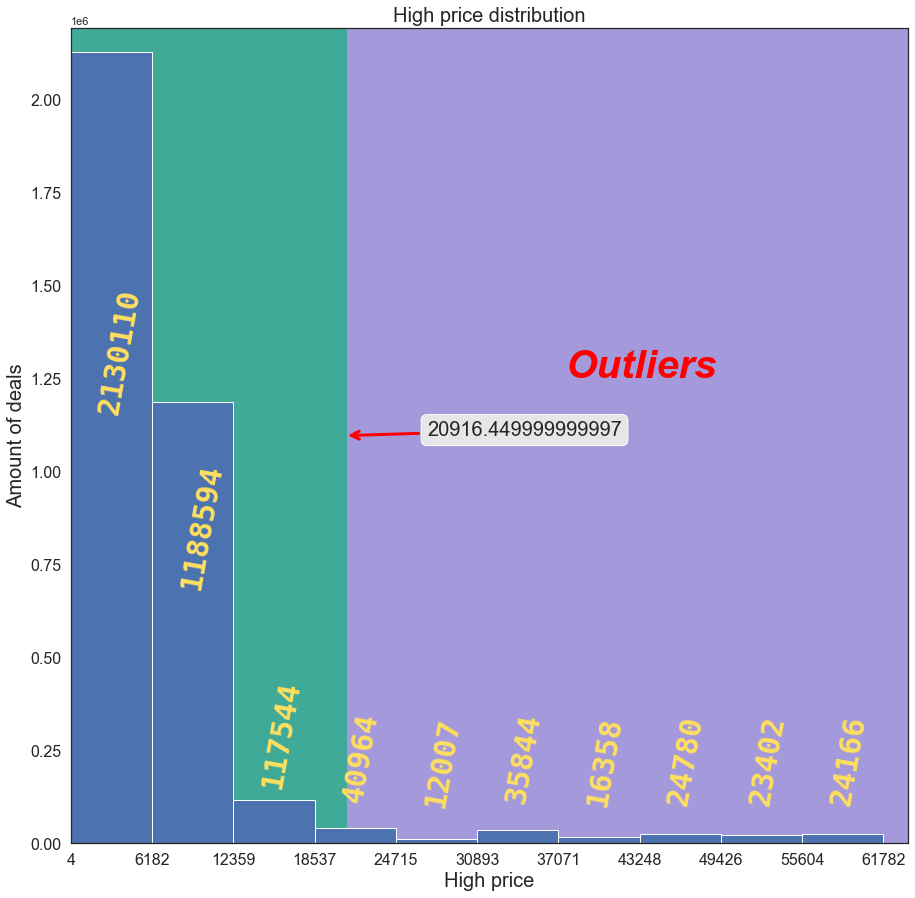

In [6]:
mean_high = df[df.keys()[2]].mean()
sd_high = df[df.keys()[2]].std(ddof=1)
b_u_high = 2.5 * df[df.keys()[2]].quantile(0.75) - 1.5 * df[df.keys()[2]].quantile(0.25)
min_high = df[df.keys()[2]].min()
left_border_high = min_high * 0.97
max_high = df[df.keys()[2]].max()
right_border_high = max_high * 1.03
interval_high = (max_high - min_high) / 10
maximum_high = len(df[df[df.keys()[2]] <= min_high + interval_high])
amounts_high = [maximum_high]
for i in range (1,10):
    possible_max = len(df[(df[df.keys()[2]] > min_high + i * interval_high)
                        & (df[df.keys()[2]] <= min_high + (i + 1) * interval_high)])
    amounts_high.append(possible_max)
    if maximum_high < possible_max:
        maximum_high = possible_max
ceil_high = maximum_high * 1.03
amount_high = len(df[df.keys()[2]])
amount_na_high = df[df.keys()[2]].isna().sum()
amount_filled_high = len(df[df.keys()[2]]) - amount_na_high
outliers_amount_high = len(df[df[df.keys()[2]] > b_u_high])
outliers_percent_high = outliers_amount_high * 100 / amount_filled_high
non_outliers_amount_high = len(df[df[df.keys()[2]] <= b_u_high])
c_v_high = sd_high / mean_high

plt.axis([left_border_high, right_border_high, 0, ceil_high])
ticks_high = [min_high]
for i in range (1, 11):
    ticks_high.append(i * interval_high + min_high)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xticks(ticks_high)
plt.xlabel(df.keys()[2] + ' price', font_label)
plt.ylabel('Amount of deals', font_label)
plt.title(df.keys()[2] + ' price distribution', font_label)
plt.gca().add_patch(patches.Rectangle((b_u_high, 0),
                                      right_border_high - b_u_high,
                                      ceil_high,
                                      color='#A499DB'))
plt.gca().add_patch(patches.Rectangle((0, 0), b_u_high, ceil_high, color='#3FAA98'))
plt.annotate(b_u_high,
             xy=(b_u_high, ceil_high / 2),
             xytext=(b_u_high + interval_high, ceil_high / 2),
             fontsize=20,
             arrowprops=arrow,
             bbox=annotation_box)
plt.gca().text((right_border_high + b_u_high) / 2.25,
               ceil_high / 1.75,
               'Outliers',
               outliers_text)
for i in range (0, 10):
        plt.gca().text(((i + 0.3) * interval_high),
                       amounts_high[i] / 2 + 10 ** 5,
                       amounts_high[i],
                       amount_text,
                       rotation=80)
plt.grid(True)
plt.hist(df[df.keys()[2]]);

In [7]:
print(f'Среднее значение High:\t\t\t\t\t\t\t\t\t{mean_high}\n'
f'Среднеквадратическое отклонение High:\t\t\t\t\t\t\t{sd_high}\n'
f'Коэффициент вариации High:\t\t\t\t\t\t\t\t{c_v_high}\n'
f'Верхняя граница межквартильного диапазона High:\t\t\t\t\t\t{b_u_high}\n'
f'Количество значений High всего:\t\t\t\t\t\t\t\t{amount_high}\n'
f'Количество пропущенных значений High:\t\t\t\t\t\t\t{amount_na_high}\n'
f'Количество значений High без пропущенных:\t\t\t\t\t\t{amount_filled_high}\n'
f'Количество выбросов High:\t\t\t\t\t\t\t\t{outliers_amount_high}\n'
f'Процент выбросов (от общего значения High без пропущенных):\t\t\t\t{outliers_percent_high}\n'
f'Количество значений High без выбросов:\t\t\t\t\t\t\t{non_outliers_amount_high}')

Среднее значение High:									6013.357081609536
Среднеквадратическое отклонение High:							9003.521006376617
Коэффициент вариации High:								1.4972536778020062
Верхняя граница межквартильного диапазона High:						20916.449999999997
Количество значений High всего:								4857377
Количество пропущенных значений High:							1243608
Количество значений High без пропущенных:						3613769
Количество выбросов High:								149758
Процент выбросов (от общего значения High без пропущенных):				4.144094434370321
Количество значений High без выбросов:							3464011


Коэффициент вариации говорит о том, что данные очень разрознены, имеется <font size=6px>$4.1\%$</font> выбросов.

### &emsp;4. Low

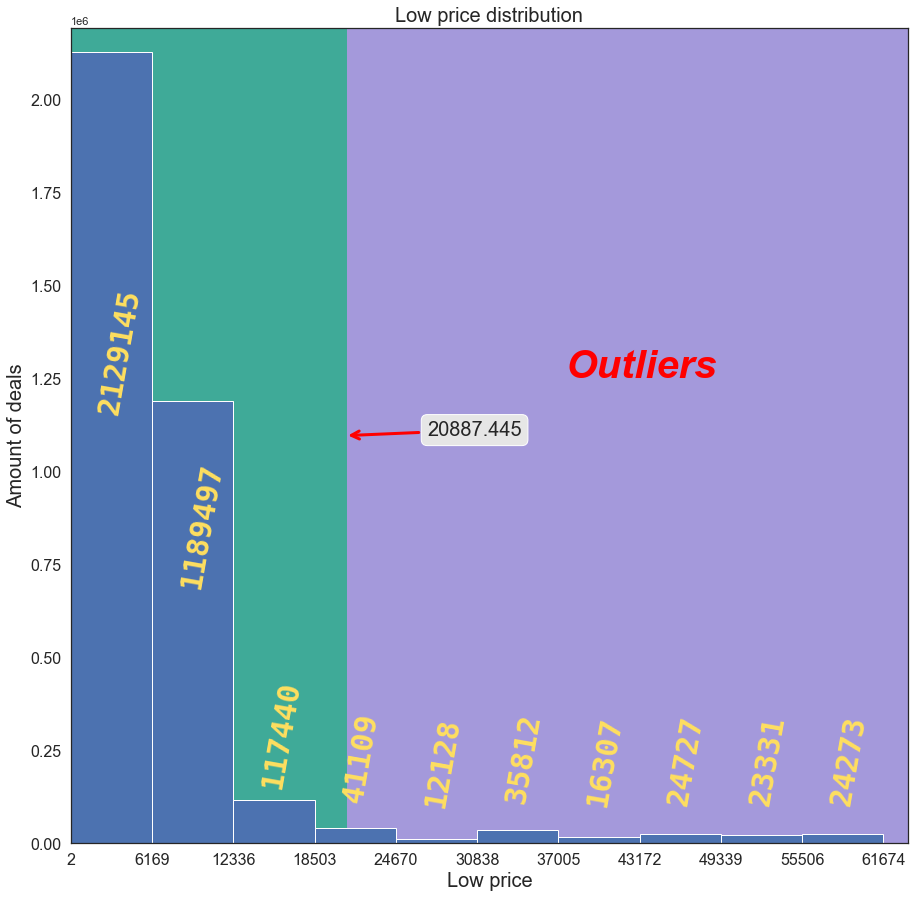

In [8]:
mean_low = df[df.keys()[3]].mean()
sd_low = df[df.keys()[3]].std(ddof=1)
b_u_low = 2.5 * df[df.keys()[3]].quantile(0.75) - 1.5 * df[df.keys()[3]].quantile(0.25)
min_low = df[df.keys()[3]].min()
left_border_low = min_low * 0.97
max_low = df[df.keys()[3]].max()
right_border_low = max_low * 1.03
interval_low = (max_low - min_low) / 10
maximum_low = len(df[df[df.keys()[3]] <= min_low + interval_low])
amounts_low = [maximum_low]
for i in range (1,10):
    possible_max = len(df[(df[df.keys()[3]] > min_low + i * interval_low)
                        & (df[df.keys()[3]] <= min_low + (i + 1) * interval_low)])
    amounts_low.append(possible_max)
    if maximum_low < possible_max:
        maximum_low = possible_max
ceil_low = maximum_low * 1.03
amount_low = len(df[df.keys()[3]])
amount_na_low = df[df.keys()[3]].isna().sum()
amount_filled_low = len(df[df.keys()[3]]) - amount_na_low
outliers_amount_low = len(df[df[df.keys()[3]] > b_u_low])
outliers_percent_low = outliers_amount_low * 100 / amount_filled_low
non_outliers_amount_low = len(df[df[df.keys()[3]] <= b_u_low])
c_v_low = sd_low / mean_low

plt.axis([left_border_low, right_border_low, 0, ceil_low])
ticks_low = [min_low]
for i in range (1, 11):
    ticks_low.append(i * interval_low + min_low)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xticks(ticks_low)
plt.xlabel(df.keys()[3] + ' price', font_label)
plt.ylabel('Amount of deals', font_label)
plt.title(df.keys()[3] + ' price distribution', font_label)
plt.gca().add_patch(patches.Rectangle((b_u_low, 0),
                                      right_border_low - b_u_low,
                                      ceil_low,
                                      color="#A499DB"))
plt.gca().add_patch(patches.Rectangle((0, 0), b_u_low, ceil_low, color='#3FAA98'))
plt.annotate(b_u_low,
             xy=(b_u_low, ceil_low / 2),
             xytext=(b_u_low + interval_low, ceil_low / 2),
             fontsize=20,
             arrowprops=arrow,
             bbox=annotation_box)
plt.gca().text((right_border_low + b_u_low) / 2.25,
               ceil_low / 1.75,
               'Outliers',
               outliers_text)
for i in range (0, 10):
        plt.gca().text((i + 0.3) * interval_low,
                       amounts_low[i] / 2 + 10 ** 5,
                       amounts_low[i],
                       amount_text,
                       rotation=80)
plt.grid(True)
plt.hist(df[df.keys()[3]]);

In [9]:
print(f'Среднее значение Low:\t\t\t\t\t\t\t\t\t{mean_low}\n'
f'Среднеквадратическое отклонение Low:\t\t\t\t\t\t\t{sd_low}\n'
f'Коэффициент вариации Low:\t\t\t\t\t\t\t\t{c_v_low}\n'
f'Верхняя граница межквартильного диапазона Low:\t\t\t\t\t\t{b_u_low}\n'
f'Количество значений Low всего:\t\t\t\t\t\t\t\t{amount_low}\n'
f'Количество пропущенных значений Low:\t\t\t\t\t\t\t{amount_na_low}\n'
f'Количество значений Low без пропущенных:\t\t\t\t\t\t{amount_filled_low}\n'
f'Количество выбросов Low:\t\t\t\t\t\t\t\t{outliers_amount_low}\n'
f'Процент выбросов (от общего значения Low без пропущенных):\t\t\t\t{outliers_percent_low}\n'
f'Количество значений Low без выбросов:\t\t\t\t\t\t\t{non_outliers_amount_low}')

Среднее значение Low:									6004.4880035062515
Среднеквадратическое отклонение Low:							8988.778318952896
Коэффициент вариации Low:								1.4970099555039502
Верхняя граница межквартильного диапазона Low:						20887.445
Количество значений Low всего:								4857377
Количество пропущенных значений Low:							1243608
Количество значений Low без пропущенных:						3613769
Количество выбросов Low:								149757
Процент выбросов (от общего значения Low без пропущенных):				4.144066762430028
Количество значений Low без выбросов:							3464012


Коэффициент вариации говорит о том, что данные очень разрознены, имеется <font size=6px>$4.1\%$</font> выбросов.

### &emsp;5. Close

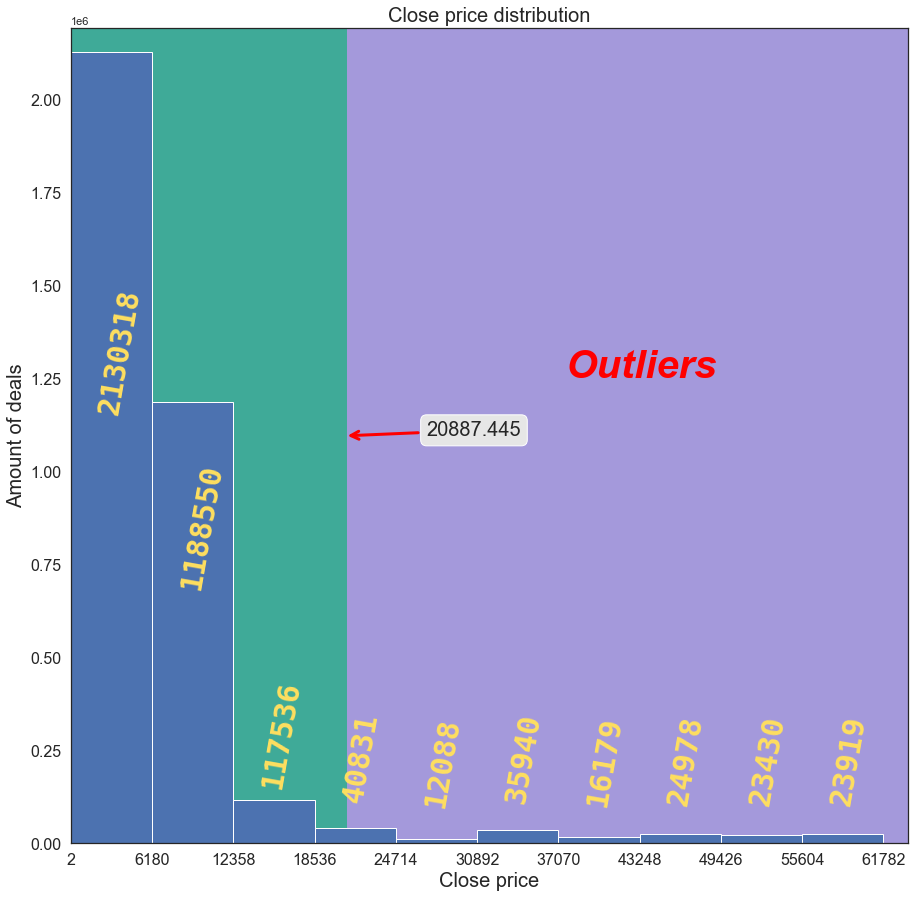

In [10]:
mean_close = df[df.keys()[4]].mean()
sd_close = df[df.keys()[4]].std(ddof=1)
b_u_close = 2.5 * df[df.keys()[4]].quantile(0.75) - 1.5 * df[df.keys()[4]].quantile(0.25)
min_close = df[df.keys()[4]].min()
left_border_close = min_close * 0.97
max_close = df[df.keys()[4]].max()
right_border_close = max_close * 1.03
interval_close = (max_close - min_close) / 10
maximum_close = len(df[df[df.keys()[4]] <= min_close + interval_close])
amounts_close = [maximum_close]
for i in range (1,10):
    possible_max = len(df[(df[df.keys()[4]] > min_close + i * interval_close)
                        & (df[df.keys()[4]] <= min_close + (i + 1) * interval_close)])
    amounts_close.append(possible_max)
    if maximum_close < possible_max:
        maximum_close = possible_max
ceil_close = maximum_close * 1.03
amount_close = len(df[df.keys()[4]])
amount_na_close = df[df.keys()[4]].isna().sum()
amount_filled_close = len(df[df.keys()[4]]) - amount_na_close
outliers_amount_close = len(df[df[df.keys()[4]] > b_u_close])
outliers_percent_close = outliers_amount_close * 100 / amount_filled_close
non_outliers_amount_close = len(df[df[df.keys()[4]] <= b_u_close])
c_v_close = sd_close / mean_close

plt.axis([left_border_close, right_border_close, 0, ceil_close])
ticks_close = [min_close]
for i in range (1, 11):
    ticks_close.append(i * interval_close + min_close)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xticks(ticks_close)
plt.xlabel(df.keys()[4] + ' price', font_label)
plt.ylabel('Amount of deals', font_label)
plt.title(df.keys()[4] + ' price distribution', font_label)
plt.gca().add_patch(patches.Rectangle((b_u_close, 0),
                                      right_border_close - b_u_close,
                                      ceil_close,
                                      color='#A499DB'))
plt.gca().add_patch(patches.Rectangle((0, 0), b_u_close, ceil_close, color='#3FAA98'))
plt.annotate(b_u_low,
             xy=(b_u_low, ceil_low / 2),
             xytext=(b_u_low + interval_low, ceil_low / 2),
             fontsize=20,
             arrowprops=arrow,
             bbox=annotation_box)
plt.gca().text((right_border_close + b_u_close) / 2.25,
               ceil_close / 1.75,
               'Outliers',
               outliers_text)
for i in range (0, 10):
        plt.gca().text((i + 0.3) * interval_close,
                       amounts_close[i] / 2 + 10 ** 5,
                       amounts_close[i],
                       amount_text,
                       rotation=80)
plt.grid(True)
plt.hist(df[df.keys()[4]]);

In [11]:
print(f'Среднее значение Close:\t\t\t\t\t\t\t\t\t{mean_close}\n'
f'Среднеквадратическое отклонение Close:\t\t\t\t\t\t\t{sd_close}\n'
f'Коэффициент вариации Close:\t\t\t\t\t\t\t\t{c_v_close}\n'
f'Верхняя граница межквартильного диапазона Close:\t\t\t\t\t{b_u_close}\n'
f'Количество значений Close всего:\t\t\t\t\t\t\t{amount_close}\n'
f'Количество пропущенных значений Close:\t\t\t\t\t\t\t{amount_na_close}\n'
f'Количество значений Close без пропущенных:\t\t\t\t\t\t{amount_filled_close}\n'
f'Количество выбросов Close:\t\t\t\t\t\t\t\t{outliers_amount_close}\n'
f'Процент выбросов (от общего значения Close без пропущенных):\t\t\t\t{outliers_percent_close}\n'
f'Количество значений Close без выбросов:\t\t\t\t\t\t\t{non_outliers_amount_close}')

Среднее значение Close:									6009.013545015653
Среднеквадратическое отклонение Close:							8996.359688354543
Коэффициент вариации Close:								1.4971441853075584
Верхняя граница межквартильного диапазона Close:					20902.11
Количество значений Close всего:							4857377
Количество пропущенных значений Close:							1243608
Количество значений Close без пропущенных:						3613769
Количество выбросов Close:								149758
Процент выбросов (от общего значения Close без пропущенных):				4.144094434370321
Количество значений Close без выбросов:							3464011


Коэффициент вариации говорит о том, что данные очень разрознены, имеется <font size=6px>$4.1\%$</font> выбросов.

### &emsp;6. Volume_(BTC)

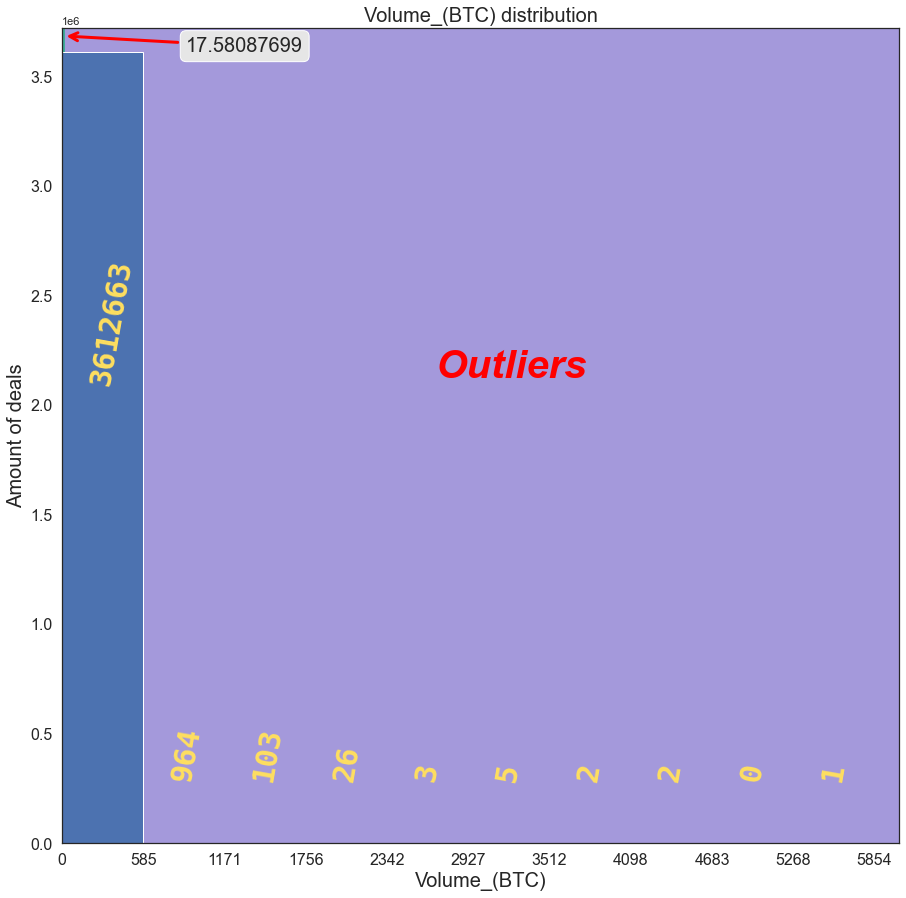

In [12]:
mean_volume_btc = df[df.keys()[5]].mean()
sd_volume_btc = df[df.keys()[5]].std(ddof=1)
b_u_volume_btc = 2.5 * df[df.keys()[5]].quantile(0.75) - 1.5 * df[df.keys()[5]].quantile(0.25)
min_volume_btc = df[df.keys()[5]].min()
left_border_volume_btc = min_volume_btc * 0.97
max_volume_btc = df[df.keys()[5]].max()
right_border_volume_btc = max_volume_btc * 1.03
interval_volume_btc = (max_volume_btc - min_volume_btc) / 10
maximum_volume_btc = len(df[df[df.keys()[5]] <= min_volume_btc + interval_volume_btc])
amounts_volume_btc = [maximum_volume_btc]
for i in range (1,10):
    possible_max = len(df[(df[df.keys()[5]] > min_volume_btc + i * interval_volume_btc)
                        & (df[df.keys()[5]] <= min_volume_btc + (i + 1) * interval_volume_btc)])
    amounts_volume_btc.append(possible_max)
    if maximum_volume_btc < possible_max:
        maximum_volume_btc = possible_max
ceil_volume_btc = maximum_volume_btc * 1.03
amount_volume_btc = len(df[df.keys()[5]])
amount_na_volume_btc = df[df.keys()[5]].isna().sum()
amount_filled_volume_btc = len(df[df.keys()[5]]) - amount_na_volume_btc
outliers_amount_volume_btc = len(df[df[df.keys()[5]] > b_u_volume_btc])
outliers_percent_volume_btc = outliers_amount_volume_btc * 100 / amount_filled_volume_btc
non_outliers_amount_volume_btc = len(df[df[df.keys()[5]] <= b_u_volume_btc])
c_v_volume_btc = sd_volume_btc / mean_volume_btc

plt.axis([left_border_volume_btc, right_border_volume_btc, 0, ceil_volume_btc])
ticks_volume_btc = [min_volume_btc]
for i in range (1, 11):
    ticks_volume_btc.append(i * interval_volume_btc + min_volume_btc)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xticks(ticks_volume_btc)
plt.xlabel(df.keys()[5], font_label)
plt.ylabel('Amount of deals', font_label)
plt.title(df.keys()[5] + ' distribution', font_label)
plt.gca().add_patch(patches.Rectangle((b_u_volume_btc, 0),
                                      right_border_volume_btc - b_u_volume_btc,
                                      ceil_volume_btc,
                                      color='#A499DB'))
plt.gca().add_patch(patches.Rectangle((0, 0), b_u_volume_btc, ceil_volume_btc, color='#3FAA98'))
plt.annotate(b_u_volume_btc,
             xy=(b_u_volume_btc, ceil_volume_btc / 1.01),
             xytext=(b_u_volume_btc + 1.5 * interval_volume_btc, ceil_volume_btc / 1.03),
             fontsize=20,
             arrowprops=arrow,
             bbox=annotation_box)
plt.gca().text((right_border_volume_btc + b_u_volume_btc) / 2.25,
               ceil_volume_btc / 1.75,
               'Outliers',
               outliers_text)
for i in range (0, 10):
        plt.gca().text((i + 0.3) * interval_volume_btc,
                       amounts_volume_btc[i] / 2 + 3 * 10 ** 5,
                       amounts_volume_btc[i],
                       amount_text,
                       rotation=80)
plt.grid(True)
plt.hist(df[df.keys()[5]]);

In [13]:
print(f'Среднее значение Volume_(BTC):\t\t\t\t\t\t\t\t\t{mean_volume_btc}\n'
f'Среднеквадратическое отклонение Volume_(BTC):\t\t\t\t\t\t\t{sd_volume_btc}\n'
f'Коэффициент вариации Volume_(BTC):\t\t\t\t\t\t\t\t{c_v_volume_btc}\n'
f'Верхняя граница межквартильного диапазона Volume_(BTC):\t\t\t\t\t\t{b_u_volume_btc}\n'
f'Количество значений Volume_(BTC) всего:\t\t\t\t\t\t\t\t{amount_volume_btc}\n'
f'Количество пропущенных значений Volume_(BTC):\t\t\t\t\t\t\t{amount_na_volume_btc}\n'
f'Количество значений Volume_(BTC) без пропущенных:\t\t\t\t\t\t{amount_filled_volume_btc}\n'
f'Количество выбросов Volume_(BTC):\t\t\t\t\t\t\t\t{outliers_amount_volume_btc}\n'
f'Процент выбросов (от общего значения Volume_(BTC) без пропущенных):\t\t\t\t{outliers_percent_volume_btc}\n'
f'Количество значений Volume_(BTC) без выбросов:\t\t\t\t\t\t\t{non_outliers_amount_volume_btc}')

Среднее значение Volume_(BTC):									9.323249222687261
Среднеквадратическое отклонение Volume_(BTC):							30.549891244121838
Коэффициент вариации Volume_(BTC):								3.2767429588583252
Верхняя граница межквартильного диапазона Volume_(BTC):						17.58087699
Количество значений Volume_(BTC) всего:								4857377
Количество пропущенных значений Volume_(BTC):							1243608
Количество значений Volume_(BTC) без пропущенных:						3613769
Количество выбросов Volume_(BTC):								429707
Процент выбросов (от общего значения Volume_(BTC) без пропущенных):				11.89082644740159
Количество значений Volume_(BTC) без выбросов:							3184062


Коэффициент вариации говорит о том, что данные очень сильно разрознены, имеется <font size=6px>$11.9\%$</font> выбросов.  
Гистограмму прорисую ещё несколько раз, т.к. предыдущая не очень-то наглядна.

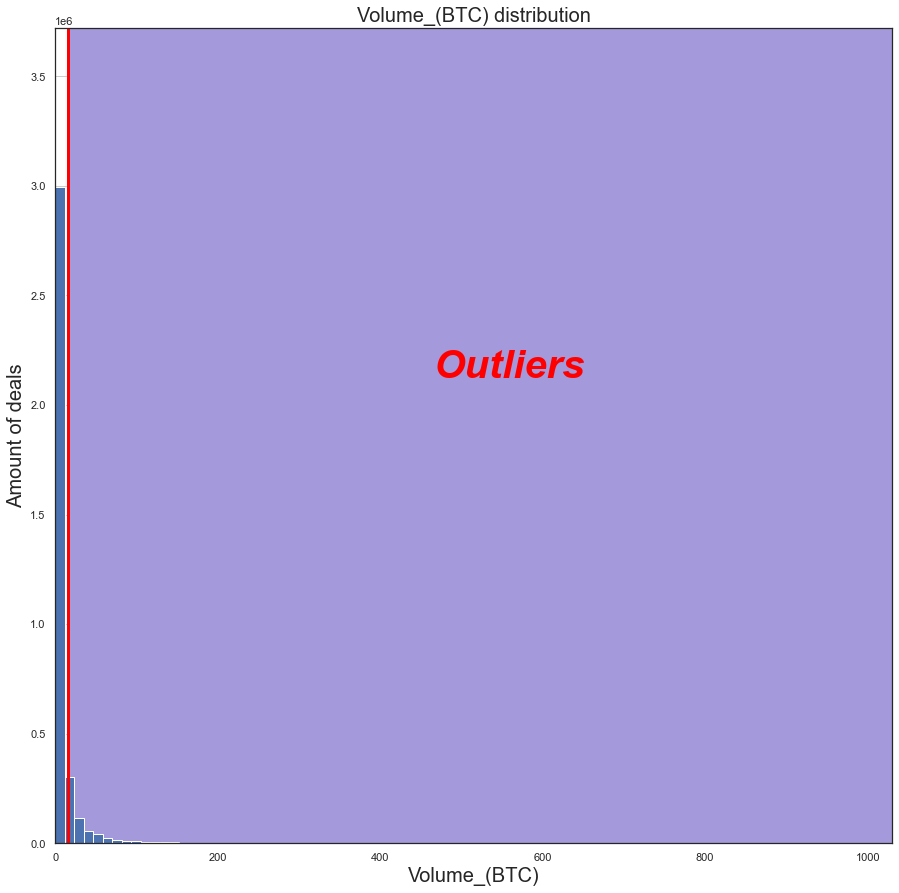

In [14]:
mean_volume_btc1 = df['Volume_(BTC)'].mean()
sd_volume_btc1 = df['Volume_(BTC)'].std(ddof=1)
Q3_volume_btc1 = df['Volume_(BTC)'].quantile(0.75)
b_u_volume_btc1 = Q3_volume_btc1 + 1.5 * (Q3_volume_btc1 - df['Volume_(BTC)'].quantile(0.25))
min_volume_btc1 = df['Volume_(BTC)'].min()
left_border_volume_btc1 = min_volume_btc1 * 0.97
max_volume_btc1 = df['Volume_(BTC)'].max() - 4853.852166
right_border_volume_btc1 = max_volume_btc1 * 1.03
interval_volume_btc1 = (df['Volume_(BTC)'].max() - df['Volume_(BTC)'].min()) / 10
maximum_volume_btc1 = len(df[df['Volume_(BTC)'] <= min_volume_btc1 + interval_volume_btc1])
for i in range (1,10):
    possible_max = len(df[(df['Volume_(BTC)'] > min_volume_btc1 + i * interval_volume_btc1)
                        & (df['Volume_(BTC)'] <= min_volume_btc1 + (i + 1) * interval_volume_btc1)])
    if maximum_volume_btc1 < possible_max:
        maximum_volume_btc1 = possible_max
ceil_volume_btc1 = maximum_volume_btc1 * 1.03

plt.axis([left_border_volume_btc1, right_border_volume_btc1, 0, ceil_volume_btc1])
plt.xlabel('Volume_(BTC)', fontsize=20)
plt.ylabel('Amount of deals', fontsize=20)
plt.title('Volume_(BTC) distribution', fontsize=20)
plt.plot([b_u_volume_btc1 - half_thicc, b_u_volume_btc1 - half_thicc], [0, ceil_volume_btc1], lw=thicc, color="red")
plt.gca().add_patch(patches.Rectangle((b_u_volume_btc1, 0), right_border_volume_btc1 - b_u_volume_btc1, ceil_volume_btc1, color="#A499DB"))
plt.gca().text((right_border_volume_btc1 + b_u_volume_btc1) / 2.25, ceil_volume_btc1 / 1.75, 'Outliers', outliers_text)
plt.grid(True)
plt.hist(df['Volume_(BTC)'], bins=500);

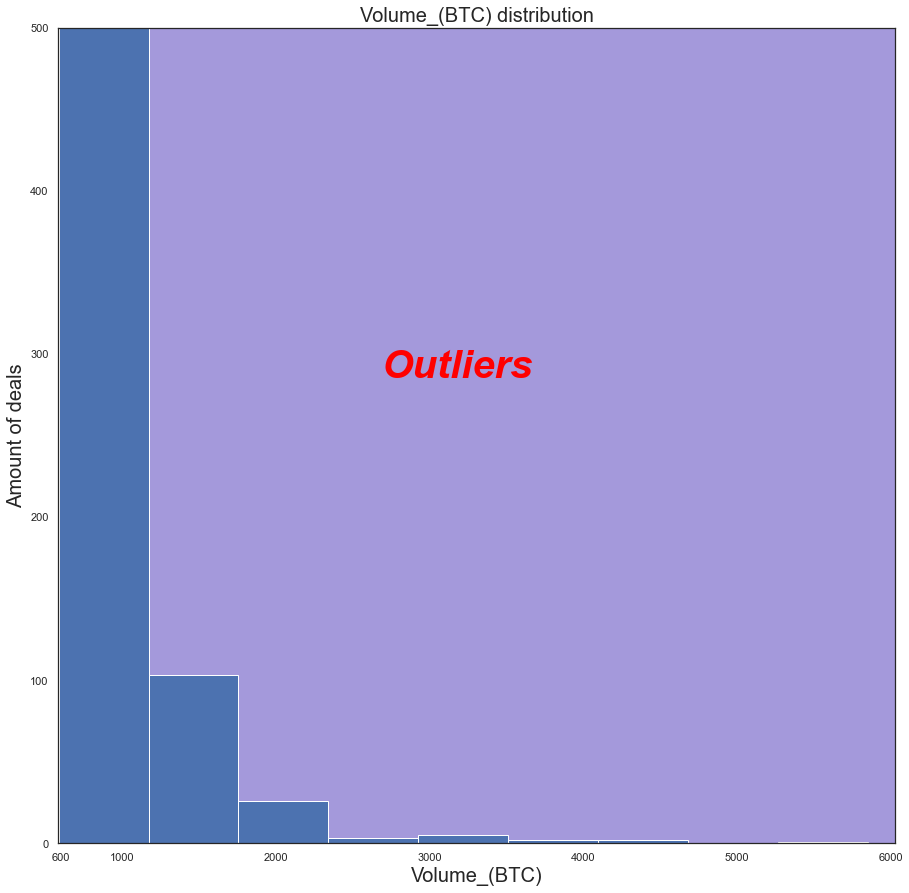

In [15]:
mean_volume_btc2 = df['Volume_(BTC)'].mean()
sd_volume_btc2 = df['Volume_(BTC)'].std(ddof=1)
Q3_volume_btc2 = df['Volume_(BTC)'].quantile(0.75)
b_u_volume_btc2 = Q3_volume_btc2 + 1.5 * (Q3_volume_btc2 - df['Volume_(BTC)'].quantile(0.25))
min_volume_btc2 = df['Volume_(BTC)'].min() + 600
left_border_volume_btc2 = min_volume_btc2 * 0.97
max_volume_btc2 = df['Volume_(BTC)'].max()
right_border_volume_btc2 = max_volume_btc2 * 1.03
ceil_volume_btc2 = 500

plt.axis([left_border_volume_btc2, right_border_volume_btc2, 0, ceil_volume_btc2])
plt.xticks([600, 1000, 2000, 3000, 4000, 5000, 6000])
plt.xlabel('Volume_(BTC)', fontsize=20)
plt.ylabel('Amount of deals', fontsize=20)
plt.title('Volume_(BTC) distribution', fontsize=20)
plt.plot([b_u_volume_btc2 - half_thicc, b_u_volume_btc2 - half_thicc], [0, ceil_volume_btc2], lw=thicc, color="red")
plt.gca().add_patch(patches.Rectangle((b_u_volume_btc2, 0), right_border_volume_btc2 - b_u_volume_btc2, ceil_volume_btc2, color="#A499DB"))
plt.gca().text((right_border_volume_btc2 + b_u_volume_btc2) / 2.25, ceil_volume_btc2 / 1.75, 'Outliers', outliers_text)
plt.grid(True)
plt.hist(df['Volume_(BTC)']);

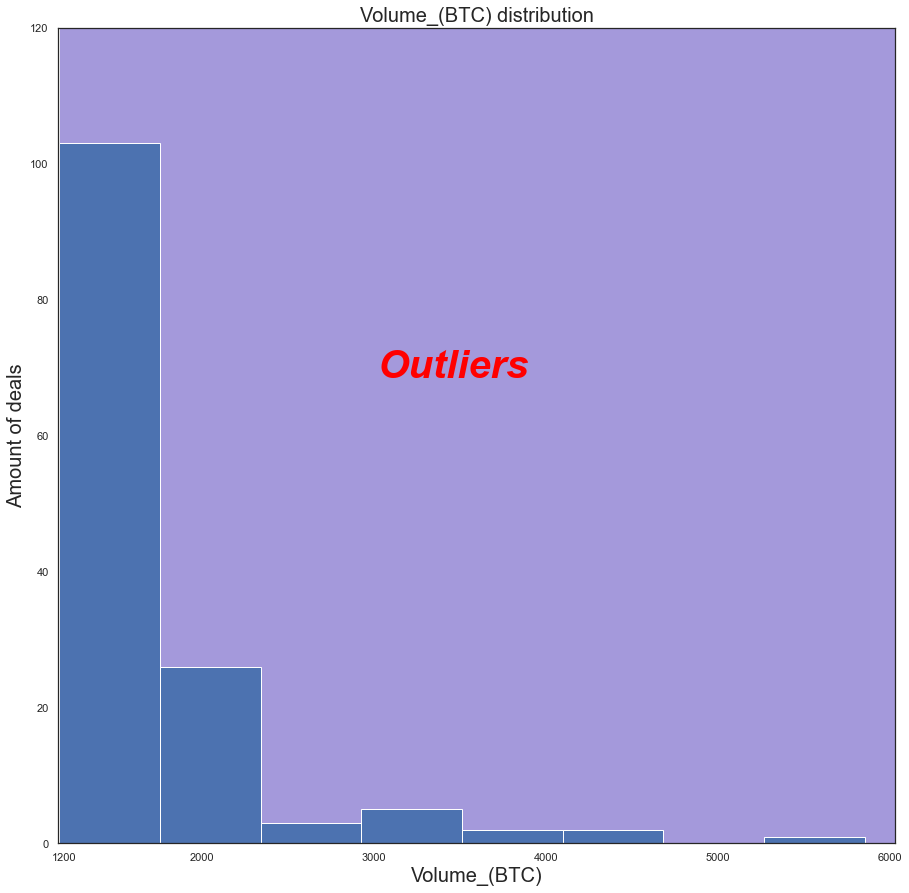

In [16]:
mean_volume_btc3 = df['Volume_(BTC)'].mean()
sd_volume_btc3 = df['Volume_(BTC)'].std(ddof=1)
b_u_volume_btc3 = 2.5 * df['Volume_(BTC)'].quantile(0.75) - 1.5 * df['Volume_(BTC)'].quantile(0.25)
min_volume_btc3 = df['Volume_(BTC)'].min() + 1200
left_border_volume_btc3 = min_volume_btc3 * 0.97
max_volume_btc3 = df['Volume_(BTC)'].max()
right_border_volume_btc3 = max_volume_btc3 * 1.03
interval_volume_btc3 = (max_volume_btc3 - min_volume_btc3) / 10
maximum_volume_btc3 = len(df[df['Volume_(BTC)'] <= min_volume_btc3 + interval_volume_btc3])
amounts_volume_btc3 = [maximum_volume_btc3]
for i in range (1,10):
    possible_max = len(df[(df['Volume_(BTC)'] > min_volume_btc3 + i * interval_volume_btc3)
                        & (df['Volume_(BTC)'] <= min_volume_btc3 + (i + 1) * interval_volume_btc3)])
    amounts_volume_btc3.append(possible_max)
    if maximum_volume_btc3 < possible_max:
        maximum_volume_btc3 = possible_max
ceil_volume_btc3 = 120

plt.axis([left_border_volume_btc3, right_border_volume_btc3, 0, ceil_volume_btc3])
plt.xticks([1200, 2000, 3000, 4000, 5000, 6000])
plt.xlabel('Volume_(BTC)', fontsize=20)
plt.ylabel('Amount of deals', fontsize=20)
plt.title('Volume_(BTC) distribution', fontsize=20)
plt.plot([b_u_volume_btc3 - half_thicc, b_u_volume_btc3 - half_thicc], [0, ceil_volume_btc3], lw=thicc, color="red")
plt.gca().add_patch(patches.Rectangle((b_u_volume_btc3, 0), right_border_volume_btc3 - b_u_volume_btc3, ceil_volume_btc3, color="#A499DB"))
plt.gca().text((right_border_volume_btc3 + b_u_volume_btc3) / 2, ceil_volume_btc3 / 1.75, 'Outliers', outliers_text)

plt.grid(True)
plt.hist(df['Volume_(BTC)']);

### &emsp;7. Volume_(Currency)

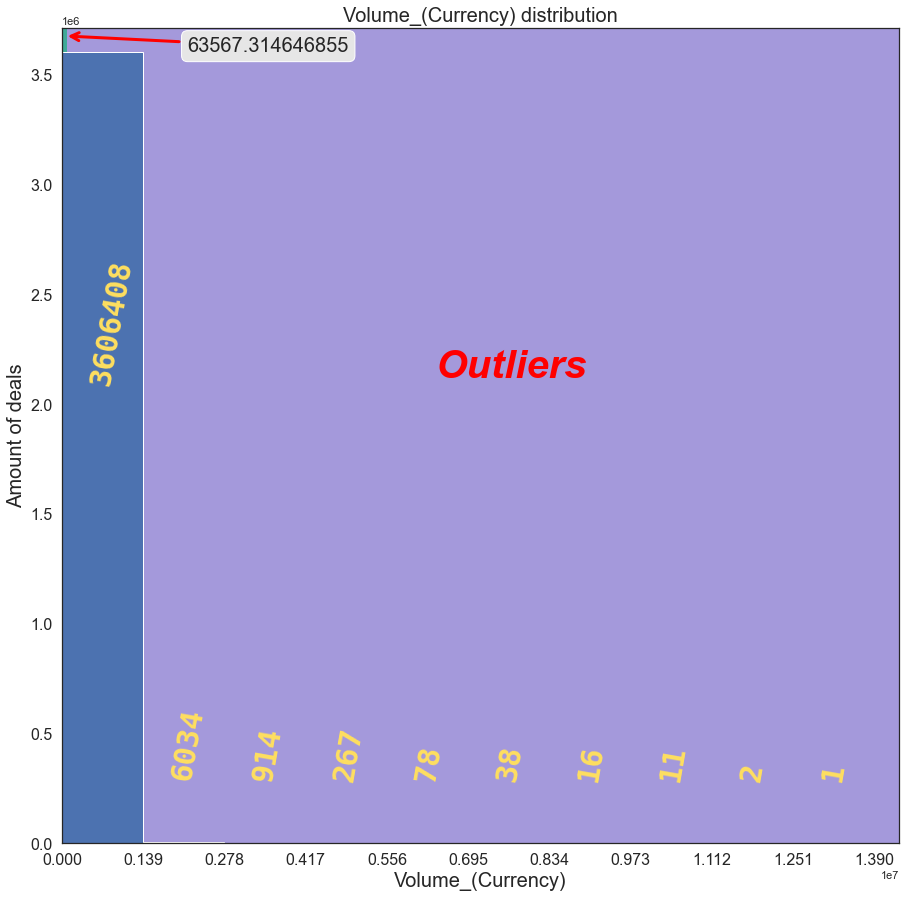

In [17]:
mean_volume_currency = df[df.keys()[6]].mean()
sd_volume_currency = df[df.keys()[6]].std(ddof=1)
b_u_volume_currency = 2.5 * df[df.keys()[6]].quantile(0.75) - 1.5 * df[df.keys()[6]].quantile(0.25)
min_volume_currency = df[df.keys()[6]].min()
left_border_volume_currency = min_volume_currency * 0.97
max_volume_currency = df[df.keys()[6]].max()
right_border_volume_currency = max_volume_currency * 1.03
interval_volume_currency = (max_volume_currency - min_volume_currency) / 10
maximum_volume_currency = len(df[df[df.keys()[6]] <= min_volume_currency + interval_volume_currency])
amounts_volume_currency = [maximum_volume_currency]
for i in range (1,10):
    possible_max = len(df[(df[df.keys()[6]] > min_volume_currency + i * interval_volume_currency)
                        & (df[df.keys()[6]] <= min_volume_currency + (i + 1) * interval_volume_currency)])
    amounts_volume_currency.append(possible_max)
    if maximum_volume_currency < possible_max:
        maximum_volume_currency = possible_max
ceil_volume_currency = maximum_volume_currency * 1.03
amount_volume_currency = len(df[df.keys()[6]])
amount_na_volume_currency = df[df.keys()[6]].isna().sum()
amount_filled_volume_currency = len(df[df.keys()[6]]) - amount_na_volume_currency
outliers_amount_volume_currency = len(df[df[df.keys()[6]] > b_u_volume_currency])
outliers_percent_volume_currency = outliers_amount_volume_currency * 100 / amount_filled_volume_currency
non_outliers_amount_volume_currency = len(df[df[df.keys()[6]] <= b_u_volume_currency])
c_v_volume_currency = sd_volume_currency / mean_volume_currency

plt.axis([left_border_volume_currency, right_border_volume_currency, 0, ceil_volume_currency])
ticks_volume_currency = [min_volume_currency]
for i in range (1, 11):
    ticks_volume_currency.append(i * interval_volume_currency + min_volume_currency)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xticks(ticks_volume_currency)
plt.xlabel(df.keys()[6], font_label)
plt.ylabel('Amount of deals', font_label)
plt.title(df.keys()[6] + ' distribution', font_label)
plt.gca().add_patch(patches.Rectangle((b_u_volume_currency, 0),
                                      right_border_volume_currency - b_u_volume_currency,
                                      ceil_volume_currency,
                                      color='#A499DB'))
plt.gca().add_patch(patches.Rectangle((0, 0), b_u_volume_currency, ceil_volume_currency, color='#3FAA98'))
plt.annotate(b_u_volume_currency,
             xy=(b_u_volume_currency, ceil_volume_currency / 1.01),
             xytext=(b_u_volume_currency + 1.5 * interval_volume_currency, ceil_volume_currency / 1.03),
             fontsize=20,
             arrowprops=arrow,
             bbox=annotation_box)
plt.gca().text((right_border_volume_currency + b_u_volume_currency) / 2.25,
               ceil_volume_currency / 1.75,
               'Outliers',
               outliers_text)
for i in range (0, 10):
        plt.gca().text((i + 0.3) * interval_volume_currency,
                       amounts_volume_currency[i] / 2 + 3 * 10 ** 5,
                       amounts_volume_currency[i],
                       amount_text,
                       rotation=80)
plt.grid(True)
plt.hist(df[df.keys()[6]]);

In [18]:
print(f'Среднее значение Volume_(Currency):\t\t\t\t\t\t\t\t{mean_volume_currency}\n'
f'Среднеквадратическое отклонение Volume_(Currency):\t\t\t\t\t\t{sd_volume_currency}\n'
f'Коэффициент вариации Volume_(Currency):\t\t\t\t\t\t\t\t{c_v_volume_currency}\n'
f'Верхняя граница межквартильного диапазона Volume_(Currency):\t\t\t\t\t{b_u_volume_currency}\n'
f'Количество значений Volume_(Currency) всего:\t\t\t\t\t\t\t{amount_volume_currency}\n'
f'Количество пропущенных значений Volume_(Currency):\t\t\t\t\t\t{amount_na_volume_currency}\n'
f'Количество значений Volume_(Currency) без пропущенных:\t\t\t\t\t\t{amount_filled_volume_currency}\n'
f'Количество выбросов Volume_(Currency):\t\t\t\t\t\t\t\t{outliers_amount_volume_currency}\n'
f'Процент выбросов (от общего значения Volume_(Currency) без пропущенных):\t\t\t{outliers_percent_volume_currency}\n'
f'Количество значений Volume_(Currency) без выбросов:\t\t\t\t\t\t{non_outliers_amount_volume_currency}')

Среднее значение Volume_(Currency):								41762.842397077846
Среднеквадратическое отклонение Volume_(Currency):						151824.78390068075
Коэффициент вариации Volume_(Currency):								3.635403511502942
Верхняя граница межквартильного диапазона Volume_(Currency):					63567.314646855
Количество значений Volume_(Currency) всего:							4857377
Количество пропущенных значений Volume_(Currency):						1243608
Количество значений Volume_(Currency) без пропущенных:						3613769
Количество выбросов Volume_(Currency):								502500
Процент выбросов (от общего значения Volume_(Currency) без пропущенных):			13.905149997135954
Количество значений Volume_(Currency) без выбросов:						3111269


Коэффициент вариации говорит о том, что данные очень сильно разрознены, имеется <font size=6px>$13.9\%$</font> выбросов.  
Гистограмму прорисую ещё несколько раз, т.к. предыдущая не очень-то наглядна.

### &emsp;8. Weighted_price

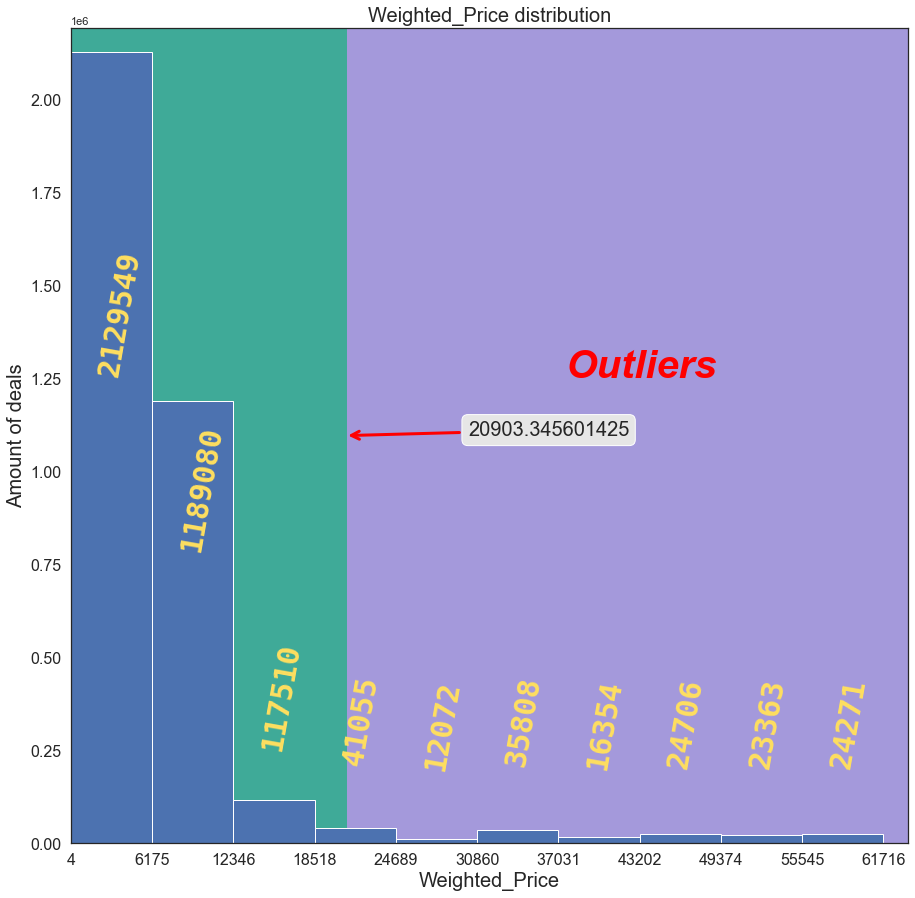

In [19]:
mean_weighted_price = df[df.keys()[7]].mean()
sd_weighted_price = df[df.keys()[7]].std(ddof=1)
b_u_weighted_price = 2.5 * df[df.keys()[7]].quantile(0.75) - 1.5 * df[df.keys()[7]].quantile(0.25)
min_weighted_price = df[df.keys()[7]].min()
left_border_weighted_price = min_weighted_price * 0.97
max_weighted_price = df[df.keys()[7]].max()
right_border_weighted_price = max_weighted_price * 1.03
interval_weighted_price = (max_weighted_price - min_weighted_price) / 10
maximum_weighted_price = len(df[df[df.keys()[7]] <= min_weighted_price + interval_weighted_price])
amounts_weighted_price = [maximum_weighted_price]
for i in range (1,10):
    possible_max = len(df[(df[df.keys()[7]] > min_weighted_price + i * interval_weighted_price)
                        & (df[df.keys()[7]] <= min_weighted_price + (i + 1) * interval_weighted_price)])
    amounts_weighted_price.append(possible_max)
    if maximum_weighted_price < possible_max:
        maximum_weighted_price = possible_max
ceil_weighted_price = maximum_weighted_price * 1.03
amount_weighted_price = len(df[df.keys()[7]])
amount_na_weighted_price = df[df.keys()[7]].isna().sum()
amount_filled_weighted_price = len(df[df.keys()[7]]) - amount_na_weighted_price
outliers_amount_weighted_price = len(df[df[df.keys()[7]] > b_u_weighted_price])
outliers_percent_weighted_price = outliers_amount_weighted_price * 100 / amount_filled_weighted_price
non_outliers_amount_weighted_price = len(df[df[df.keys()[7]] <= b_u_weighted_price])
c_v_weighted_price = sd_weighted_price / mean_weighted_price

plt.axis([left_border_weighted_price, right_border_weighted_price, 0, ceil_weighted_price])
ticks_weighted_price = [min_weighted_price]
for i in range (1, 11):
    ticks_weighted_price.append(i * interval_weighted_price + min_weighted_price)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xticks(ticks_weighted_price)
plt.xlabel(df.keys()[7], font_label)
plt.ylabel('Amount of deals', font_label)
plt.title(df.keys()[7] + ' distribution', font_label)
plt.gca().add_patch(patches.Rectangle((b_u_weighted_price, 0),
                                      right_border_weighted_price - b_u_weighted_price,
                                      ceil_weighted_price,
                                      color='#A499DB'))
plt.gca().add_patch(patches.Rectangle((0, 0), b_u_weighted_price, ceil_weighted_price, color='#3FAA98'))
plt.annotate(b_u_weighted_price,
             xy=(b_u_weighted_price, ceil_weighted_price / 2),
             xytext=(b_u_weighted_price + 1.5 * interval_weighted_price, ceil_weighted_price / 2),
             fontsize=20,
             arrowprops=arrow,
             bbox=annotation_box)
plt.gca().text((right_border_weighted_price + b_u_weighted_price) / 2.25,
               ceil_weighted_price / 1.75,
               'Outliers',
               outliers_text)
for i in range (0, 10):
        plt.gca().text((i + 0.3) * interval_weighted_price,
                       amounts_weighted_price[i] / 2 + 2 * 10 ** 5,
                       amounts_weighted_price[i],
                       amount_text,
                       rotation=80)
plt.grid(True)
plt.hist(df[df.keys()[7]]);

In [20]:
print(f'Среднее значение Weighted_Price:\t\t\t\t\t\t\t\t{mean_weighted_price}\n'
f'Среднеквадратическое отклонение Weighted_Price:\t\t\t\t\t\t\t{sd_weighted_price}\n'
f'Коэффициент вариации Weighted_Price:\t\t\t\t\t\t\t\t{c_v_weighted_price}\n'
f'Верхняя граница межквартильного диапазона Weighted_Price:\t\t\t\t\t{b_u_weighted_price}\n'
f'Количество значений Weighted_Price всего:\t\t\t\t\t\t\t{amount_weighted_price}\n'
f'Количество пропущенных значений Weighted_Price:\t\t\t\t\t\t\t{amount_na_weighted_price}\n'
f'Количество значений Weighted_Price без пропущенных:\t\t\t\t\t\t{amount_filled_weighted_price}\n'
f'Количество выбросов Weighted_Price:\t\t\t\t\t\t\t\t{outliers_amount_weighted_price}\n'
f'Процент выбросов (от общего значения Weighted_Price без пропущенных):\t\t\t\t{outliers_percent_weighted_price}\n'
f'Количество значений Weighted_Price без выбросов:\t\t\t\t\t\t{non_outliers_amount_weighted_price}')

Среднее значение Weighted_Price:								6008.9348002888655
Среднеквадратическое отклонение Weighted_Price:							8995.99164341298
Коэффициент вариации Weighted_Price:								1.4971025551784183
Верхняя граница межквартильного диапазона Weighted_Price:					20903.345601425
Количество значений Weighted_Price всего:							4857377
Количество пропущенных значений Weighted_Price:							1243608
Количество значений Weighted_Price без пропущенных:						3613769
Количество выбросов Weighted_Price:								149758
Процент выбросов (от общего значения Weighted_Price без пропущенных):				4.144094434370321
Количество значений Weighted_Price без выбросов:						3464011


Коэффициент вариации говорит о том, что данные сильно разрознены, имеется <font size=6px>$4.1\%$</font> выбросов.

## 4. <a href="#toc" title="К содержанию" id="attributes-correlation" style="text-decoration: none; color:#81BCD9">Анализ корреляции атрибутов</a>
***

- Для того, чтобы отобразить таблицу корреляции между атрибутами буду использовать команду
    - ```python
    df.corr()
    ```
- Для построения матрицы графиков рассеивания буду использовать команду
    - ```python
    sns.pairplot(df);
    ```

In [21]:
df.corr()

,Timestamp,Open,High,Low,Close,Volume_(BTC),Volume_(Currency),Weighted_Price
Timestamp,1.000000,0.650719,0.650644,0.650803,0.650714,-0.103926,0.228190,0.650737
Open,0.650719,1.000000,0.999999,0.999999,0.999999,-0.051860,0.344074,0.999999
High,0.650644,0.999999,1.000000,0.999998,0.999999,-0.051717,0.344498,0.999999
Low,0.650803,0.999999,0.999998,1.000000,0.999999,-0.052040,0.343541,1.000000
Close,0.650714,0.999999,0.999999,0.999999,1.000000,-0.051877,0.344036,1.000000
Volume_(BTC),-0.103926,-0.051860,-0.051717,-0.052040,-0.051877,1.000000,0.352038,-0.051887
Volume_(Currency),0.228190,0.344074,0.344498,0.343541,0.344036,0.352038,1.000000,0.344010
Weighted_Price,0.650737,0.999999,0.999999,1.000000,1.000000,-0.051887,0.344010,1.000000


Как видно из таблицы, атрибутов, не имеющих корреляцию, нет.

Однако, атрибут **Volume_(BTC)** слабо коррелирует (слабо относительно других атрибутов) со всеми атрибутами, кроме **Volume_(Currency)**.<br>
Все остальные атрибуты высоко коррелируют между собой, особенно это касается цен на торгах: **Open**, **High**, **Low** и **Close**, а также **Weighted_Price**.

**Volume_(BTC)** имеет отрицательную корреляцию со всеми атрибутами, кроме всё той же **Volume_(Currency)**.<br>
Прочие же атрибуты имеют положительную корреляцию.

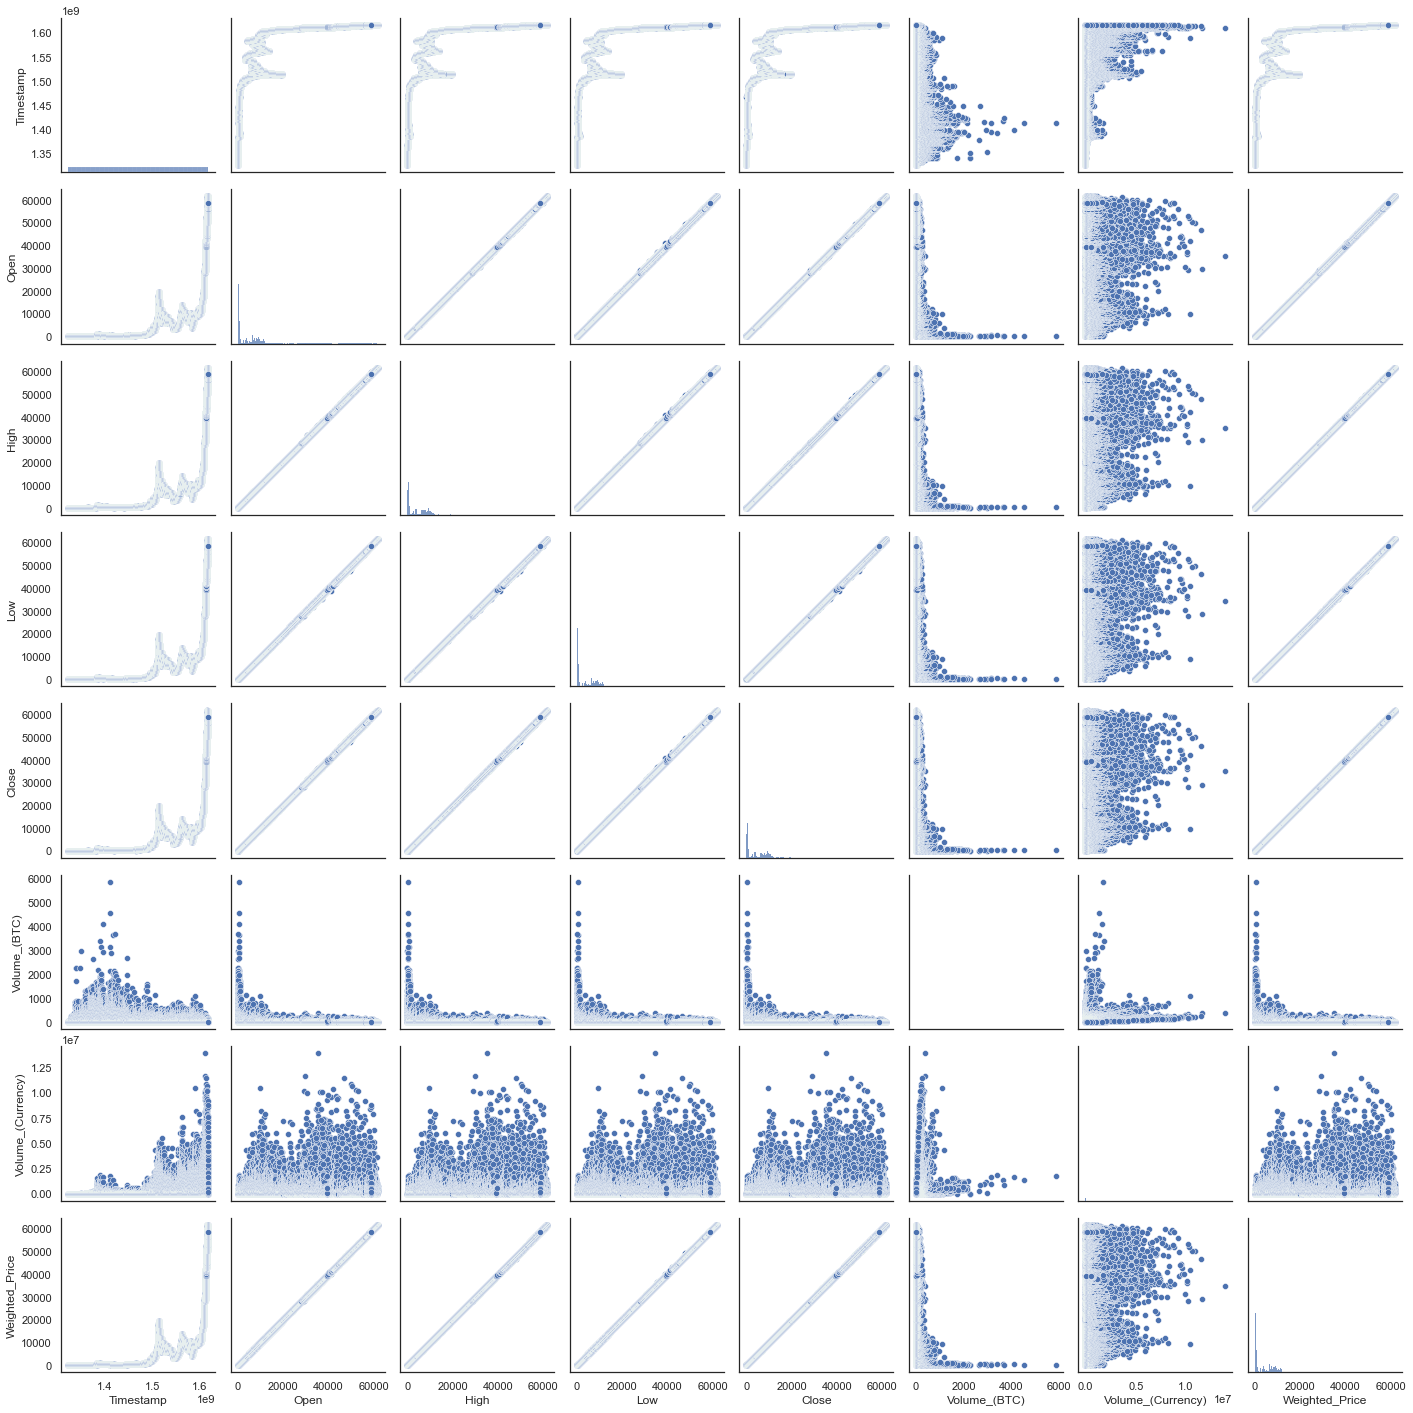

In [22]:
sns.pairplot(df);

- Проанализируйте полученные результаты.